In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import cleaning_stephanie as cs
import seaborn as sns

In [4]:
#Name_Air_Temp = "Manning_AGDM_air_temp_precip.txt"
#Name_Humidity = "Manning_AGDM_humidity_wind_radiation.txt"
Name_Soil_Temp = "Manning_AGDM.csv"
Name_Soil_Mois= "Manning AGDM.csv"

#Manning AGDM

## Soil Temp

In [5]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Temp)
df_Soil_Temp_AGDM.head()

,time,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
0,2005-05-01 00:00:00,0.1,0.7,1.2,-0.4
1,2005-05-01 01:00:00,0.0,0.8,1.2,-0.4
2,2005-05-01 02:00:00,0.0,0.7,1.2,-0.4
3,2005-05-01 03:00:00,-0.0,0.7,1.2,-0.4
4,2005-05-01 04:00:00,-0.0,0.7,1.2,-0.3


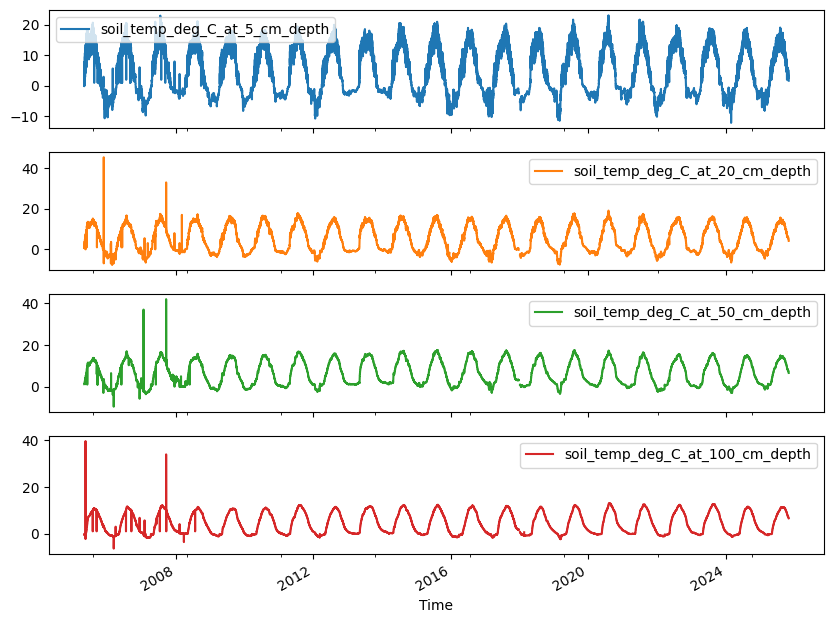

In [6]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [7]:
df_Soil_Temp_AGDM.mean()

,0
soil_temp_deg_C_at_5_cm_depth,4.565529
soil_temp_deg_C_at_20_cm_depth,5.201754
soil_temp_deg_C_at_50_cm_depth,6.449308
soil_temp_deg_C_at_100_cm_depth,4.561113


In [8]:
df_Soil_Temp_AGDM.max()

,0
soil_temp_deg_C_at_5_cm_depth,23.1
soil_temp_deg_C_at_20_cm_depth,45.4
soil_temp_deg_C_at_50_cm_depth,42.0
soil_temp_deg_C_at_100_cm_depth,39.7


In [9]:
df_Soil_Temp_AGDM.min()

,0
soil_temp_deg_C_at_5_cm_depth,-12.1
soil_temp_deg_C_at_20_cm_depth,-7.6
soil_temp_deg_C_at_50_cm_depth,-9.6
soil_temp_deg_C_at_100_cm_depth,-6.4


In [10]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_temp_deg_C_at_5_cm_depth,876
soil_temp_deg_C_at_20_cm_depth,876
soil_temp_deg_C_at_50_cm_depth,876
soil_temp_deg_C_at_100_cm_depth,947


In [11]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,178851
soil_temp_deg_C_at_20_cm_depth,178851
soil_temp_deg_C_at_50_cm_depth,178851
soil_temp_deg_C_at_100_cm_depth,178780


# Specific TH Stuck
In this method we remove any set of repeated values larger than  `sens_stuck `. This method is better for the model fitting part.

##Neighborhood Outliers

This proposal eliminates an entire neighborhood of size `segment_th` surrounding any value considered an outlier. This is because, when using the returns approach, the first point might be an outlier with respect to the previous normal trend, but subsequent points will be normal with respect to the outlier. However, only the first detected outlier will be eliminated, as subsequent returns would be normal with respect to the removed outlier.

The current method looks for outliers with a positive or negative jump and searches the surroundings for an opposite jump that adjusts to the normal value without counting intermediate NaN values ​​that might be present to remove the section completely.



In [12]:
from cleaning_stephanie import soil_temp_percentil_neighborhood_outliers

###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.

In [13]:
from cleaning_stephanie import soil_temp_percentil_neighborhood_outliers

Text(0.5, 0, 'Time')

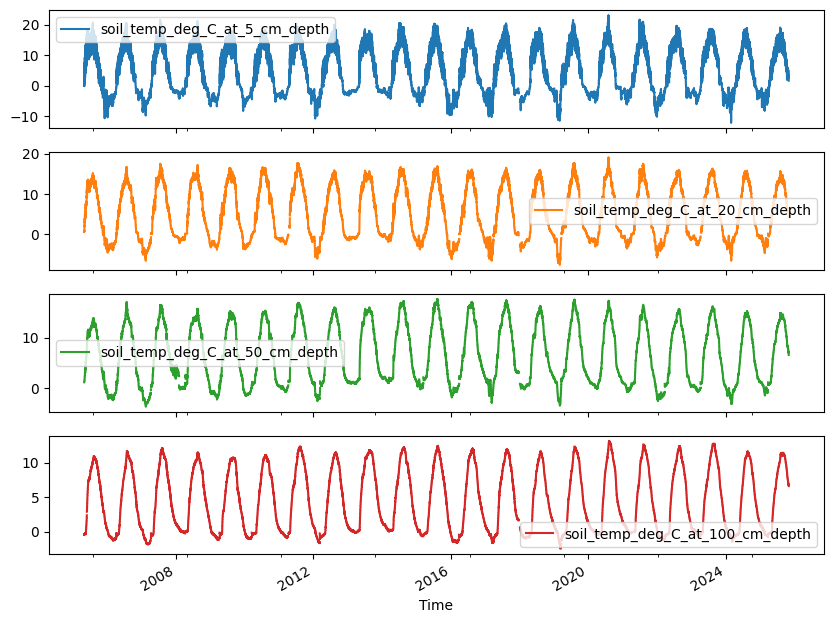

In [14]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [15]:
df_Clean_per.to_csv("Manning_AGDM_temperature_cleaned.csv")

In [16]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,23.1
soil_temp_deg_C_at_20_cm_depth,19.1
soil_temp_deg_C_at_50_cm_depth,17.6
soil_temp_deg_C_at_100_cm_depth,13.1


In [17]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-12.1
soil_temp_deg_C_at_20_cm_depth,-7.5
soil_temp_deg_C_at_50_cm_depth,-3.6
soil_temp_deg_C_at_100_cm_depth,-2.4


In [18]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,169942
soil_temp_deg_C_at_20_cm_depth,164406
soil_temp_deg_C_at_50_cm_depth,150038
soil_temp_deg_C_at_100_cm_depth,128495


In [19]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,9785
soil_temp_deg_C_at_20_cm_depth,15321
soil_temp_deg_C_at_50_cm_depth,29689
soil_temp_deg_C_at_100_cm_depth,51232


In [20]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,8909
soil_temp_deg_C_at_20_cm_depth,14445
soil_temp_deg_C_at_50_cm_depth,28813
soil_temp_deg_C_at_100_cm_depth,50285


In [21]:
df_Clean_per

,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
time,,,,
2005-05-01 00:00:00,NaN,NaN,NaN,NaN
2005-05-01 01:00:00,NaN,NaN,NaN,NaN
2005-05-01 02:00:00,0.0,0.7,1.2,-0.4
2005-05-01 03:00:00,-0.0,0.7,1.2,-0.4
2005-05-01 04:00:00,-0.0,0.7,1.2,-0.3
...,...,...,...,...
2025-10-31 19:00:00,1.7,4.2,6.7,6.6
2025-10-31 20:00:00,1.7,4.2,6.7,6.6
2025-10-31 21:00:00,1.7,4.2,6.6,6.6


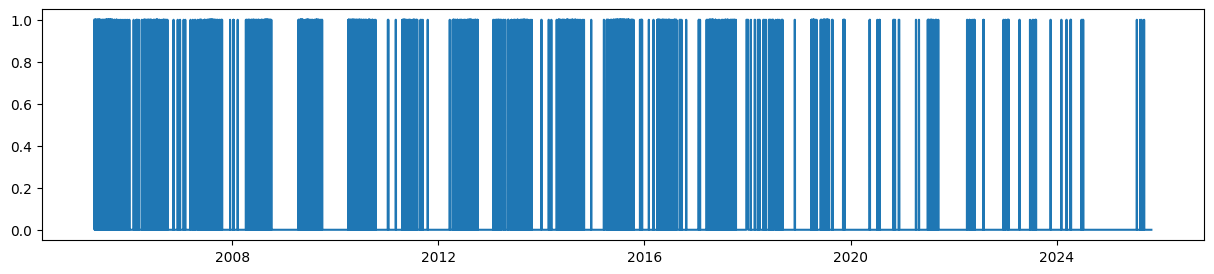

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per['soil_temp_deg_C_at_5_cm_depth'].isna())
plt.show()

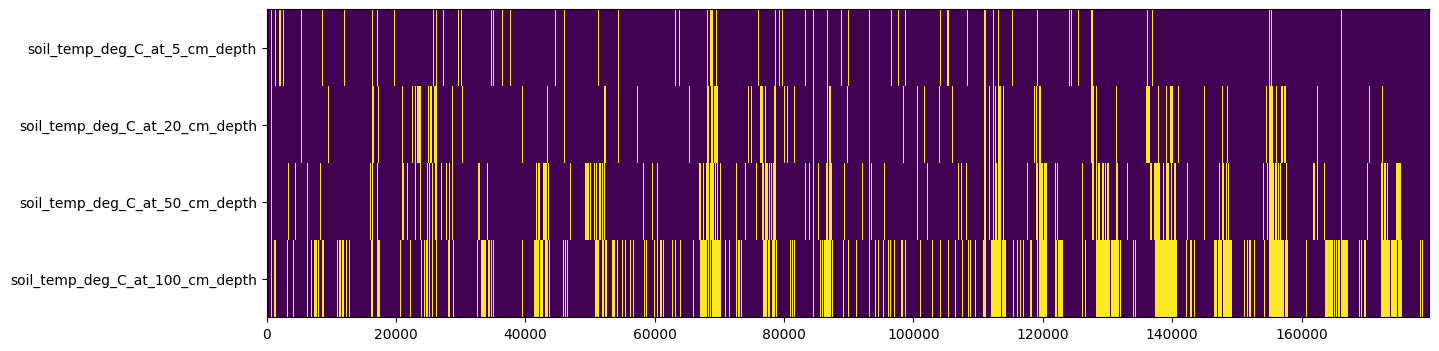

In [23]:
plt.figure(figsize=(15,4))
plt.imshow(
    df_Clean_per.isna().T,
    aspect='auto',
    interpolation='nearest'
)
plt.yticks(range(len(df_Clean_per.columns)), df_Clean_per.columns)
plt.show()

In [24]:
df_Clean_per.shape


(179727, 4)

In [25]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,9785
soil_temp_deg_C_at_20_cm_depth,15321
soil_temp_deg_C_at_50_cm_depth,29689
soil_temp_deg_C_at_100_cm_depth,51232


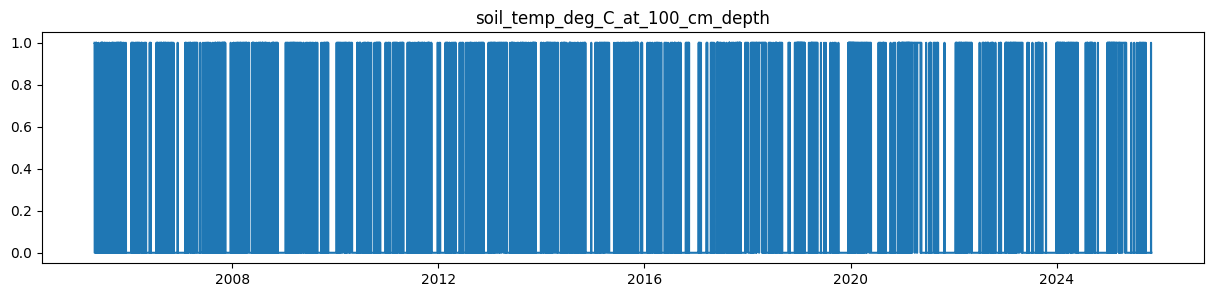

In [26]:
col = 'soil_temp_deg_C_at_100_cm_depth'

plt.figure(figsize=(15,3))
plt.plot(df_Clean_per[col].isna().astype(int))
plt.title(col)
plt.show()

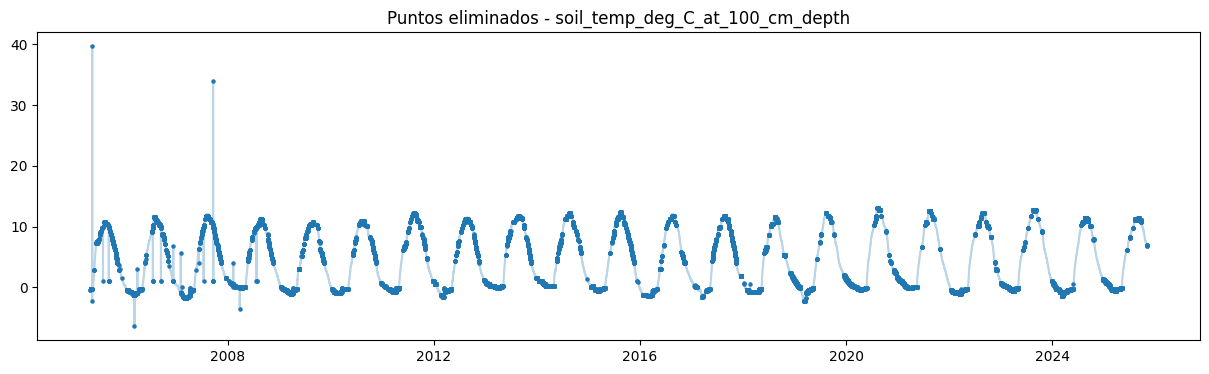

In [27]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

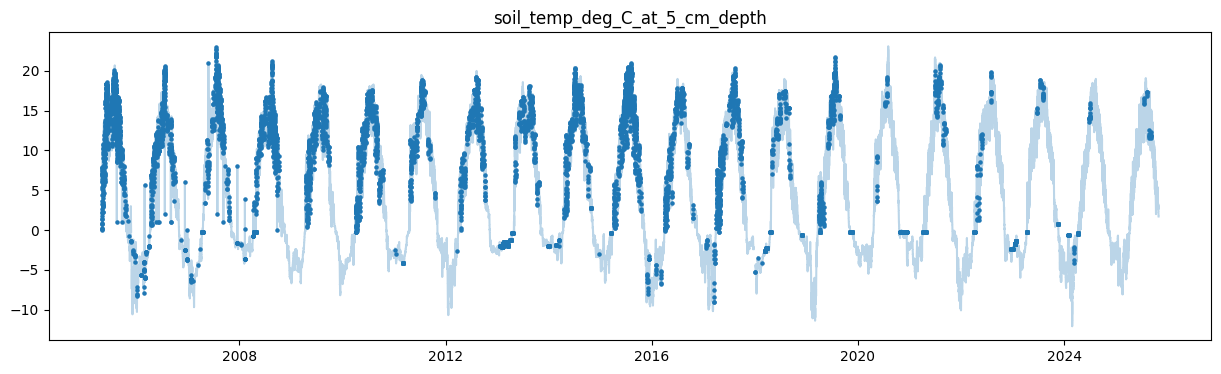

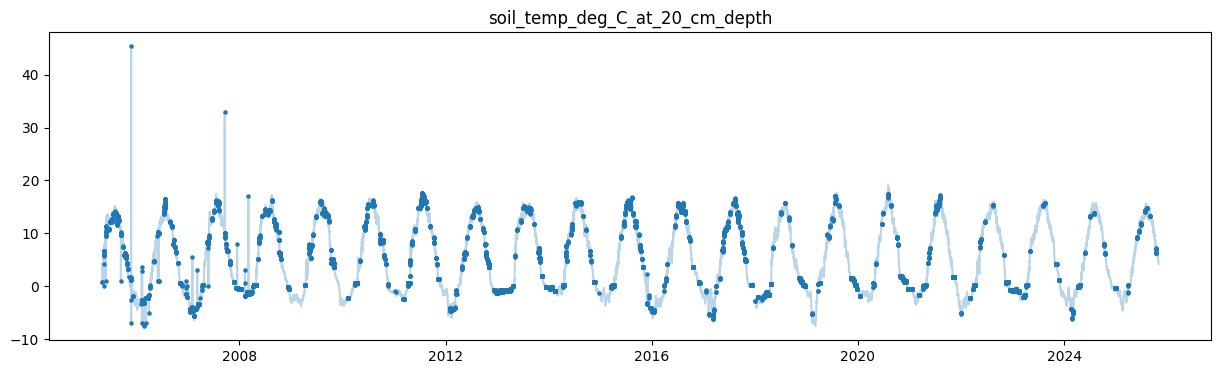

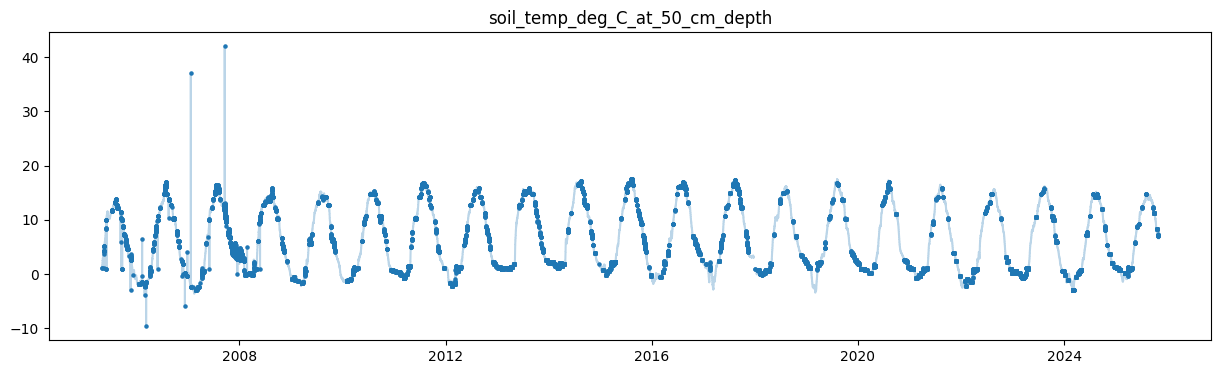

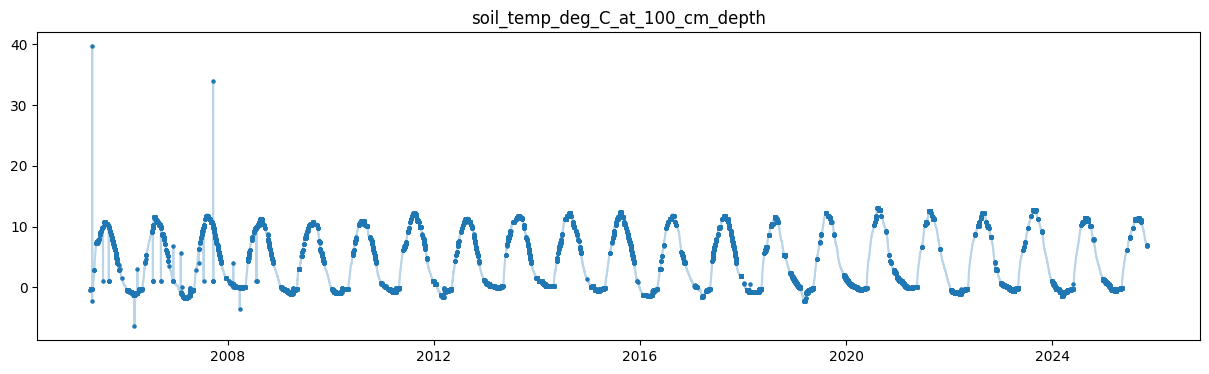

In [28]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

# Z Scores Not Used


In [29]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

Text(0.5, 0, 'Time')

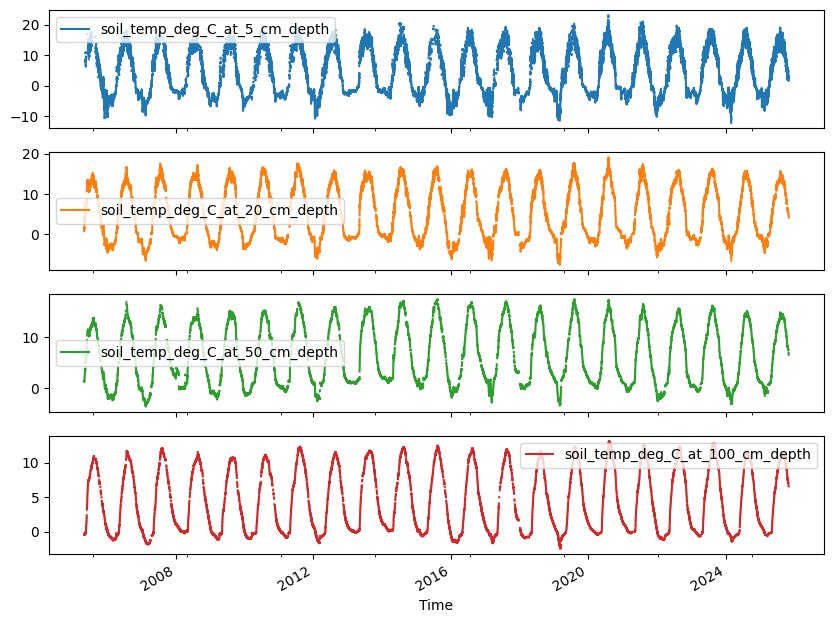

In [30]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [31]:
#df_Clean_per.to_csv("Manning_AGDM_temperature_cleaned.csv")

In [32]:
df_Clean_per.max()

,0
soil_temp_deg_C_at_5_cm_depth,23.1
soil_temp_deg_C_at_20_cm_depth,19.1
soil_temp_deg_C_at_50_cm_depth,17.5
soil_temp_deg_C_at_100_cm_depth,13.1


In [33]:
df_Clean_per.min()

,0
soil_temp_deg_C_at_5_cm_depth,-12.1
soil_temp_deg_C_at_20_cm_depth,-7.5
soil_temp_deg_C_at_50_cm_depth,-3.6
soil_temp_deg_C_at_100_cm_depth,-2.4


In [34]:
df_Clean_per.notna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,110012
soil_temp_deg_C_at_20_cm_depth,129825
soil_temp_deg_C_at_50_cm_depth,95468
soil_temp_deg_C_at_100_cm_depth,68289


In [35]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_temp_deg_C_at_5_cm_depth,69715
soil_temp_deg_C_at_20_cm_depth,49902
soil_temp_deg_C_at_50_cm_depth,84259
soil_temp_deg_C_at_100_cm_depth,111438


In [36]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_temp_deg_C_at_5_cm_depth,68839
soil_temp_deg_C_at_20_cm_depth,49026
soil_temp_deg_C_at_50_cm_depth,83383
soil_temp_deg_C_at_100_cm_depth,110491


In [37]:
df_Clean_per

,soil_temp_deg_C_at_5_cm_depth,soil_temp_deg_C_at_20_cm_depth,soil_temp_deg_C_at_50_cm_depth,soil_temp_deg_C_at_100_cm_depth
time,,,,
2005-05-01 00:00:00,NaN,NaN,NaN,NaN
2005-05-01 01:00:00,NaN,NaN,NaN,NaN
2005-05-01 02:00:00,NaN,NaN,NaN,NaN
2005-05-01 03:00:00,NaN,NaN,NaN,NaN
2005-05-01 04:00:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2025-10-31 19:00:00,1.7,4.2,6.7,6.6
2025-10-31 20:00:00,1.7,4.2,6.7,6.6
2025-10-31 21:00:00,1.7,4.2,6.6,6.6


In [38]:
df_Clean_per.isna().sum()

,0
soil_temp_deg_C_at_5_cm_depth,69715
soil_temp_deg_C_at_20_cm_depth,49902
soil_temp_deg_C_at_50_cm_depth,84259
soil_temp_deg_C_at_100_cm_depth,111438


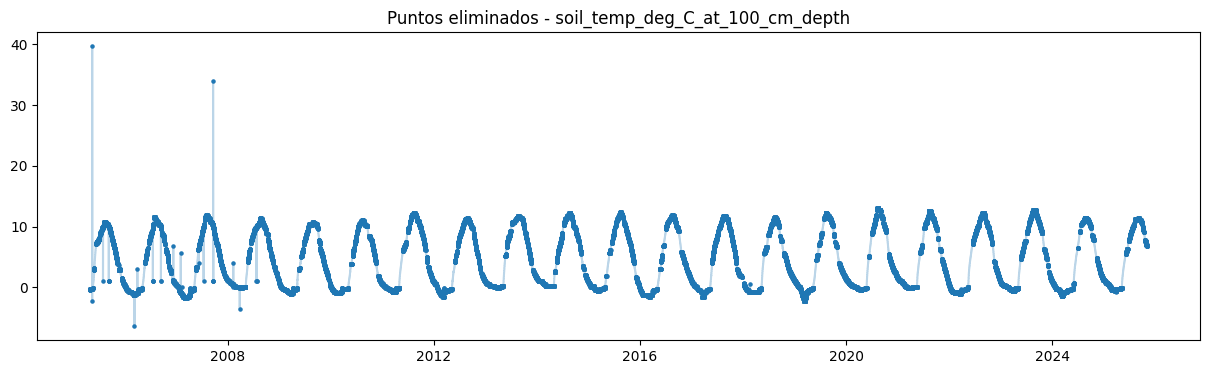

In [39]:
col = 'soil_temp_deg_C_at_100_cm_depth'

# puntos que fueron eliminados en el limpio
bad_mask = df_Clean_per[col].isna()

plt.figure(figsize=(15,4))

# serie original completa
plt.plot(df_Soil_Temp_AGDM.index,
         df_Soil_Temp_AGDM[col],
         alpha=0.3)

# puntos eliminados resaltados
plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
            df_Soil_Temp_AGDM.loc[bad_mask, col],
            s=5)

plt.title(f'Puntos eliminados - {col}')
plt.show()

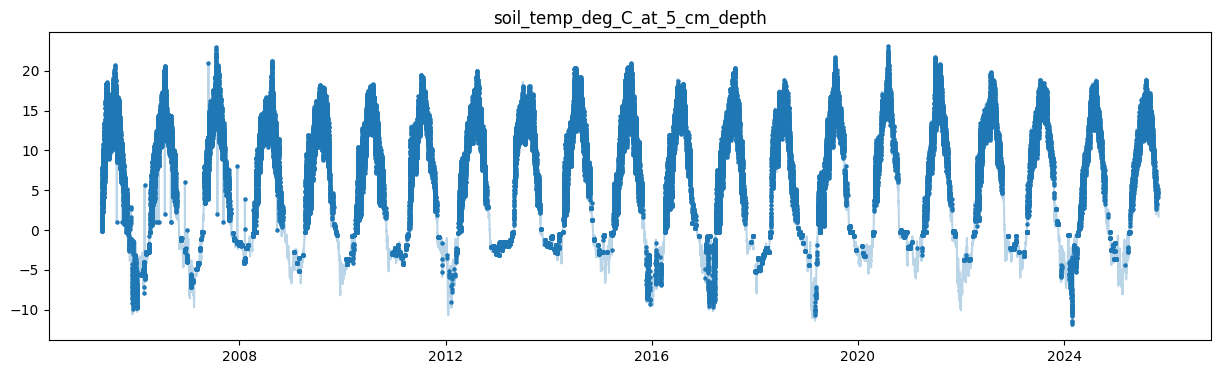

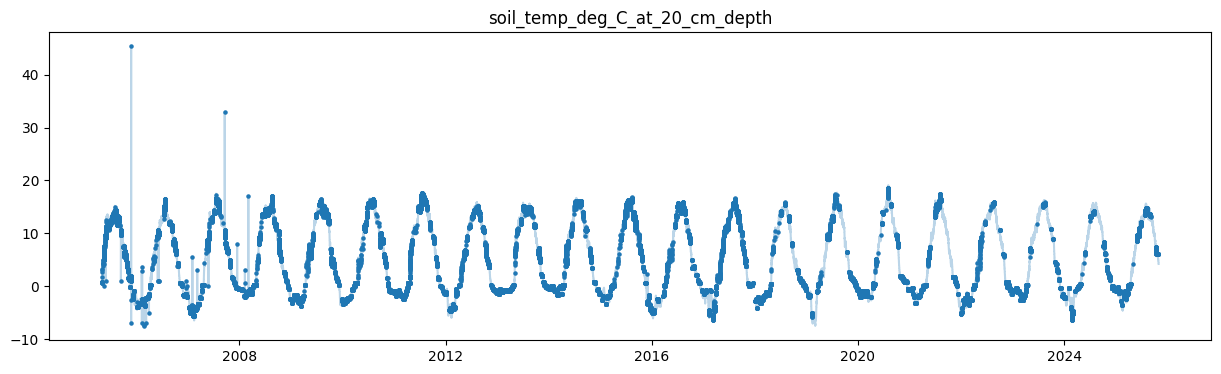

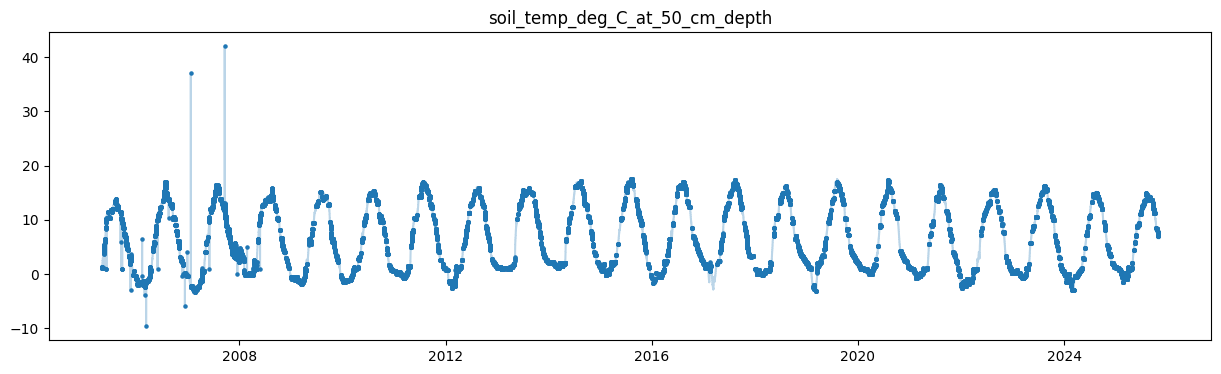

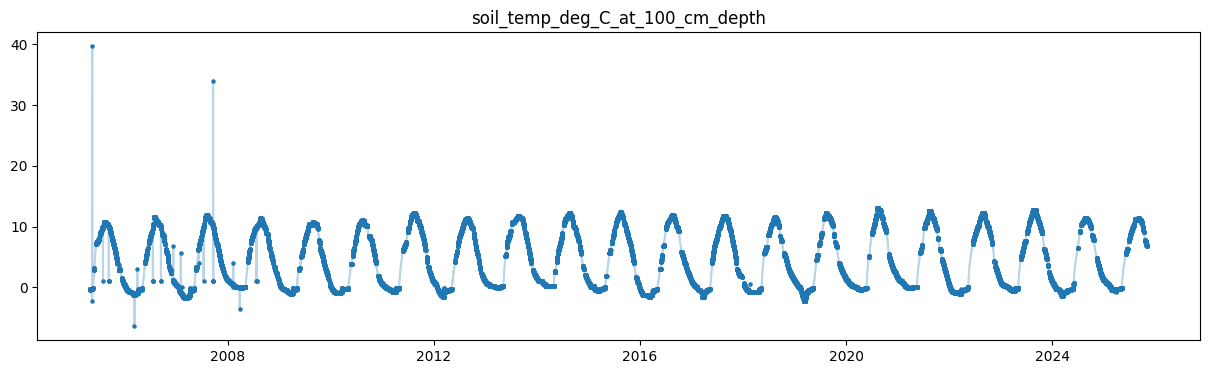

In [40]:
for col in df_Soil_Temp_AGDM.columns:

    bad_mask = (
    df_Clean_per[col].isna()
    & df_Soil_Temp_AGDM[col].notna()
    )

    plt.figure(figsize=(15,4))

    plt.plot(df_Soil_Temp_AGDM.index,
             df_Soil_Temp_AGDM[col],
             alpha=0.3)

    plt.scatter(df_Soil_Temp_AGDM.index[bad_mask],
                df_Soil_Temp_AGDM.loc[bad_mask, col],
                s=5)

    plt.title(col)
    plt.show()

# Moisture

In [41]:
df_Soil_Temp_AGDM=pd.read_csv(Name_Soil_Mois)
df_Soil_Temp_AGDM.head()

,time,soil_moisture_percent_at_5_cm_depth,soil_moisture_percent_at_20_cm_depth,soil_moisture_percent_at_50_cm_depth,soil_moisture_percent_at_100_cm_depth
0,2005-05-01 00:00:00,52.9,NaN,40.2,37.6
1,2005-05-01 01:00:00,52.9,NaN,40.2,37.6
2,2005-05-01 02:00:00,52.9,NaN,40.2,37.6
3,2005-05-01 03:00:00,52.9,NaN,40.2,37.6
4,2005-05-01 04:00:00,52.9,NaN,40.2,37.6


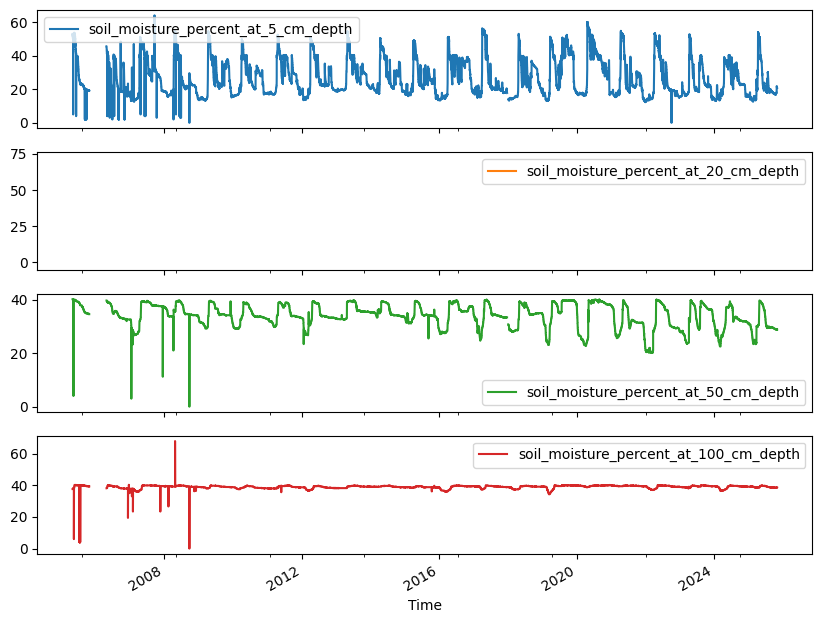

In [42]:
df_Soil_Temp_AGDM["time"] = pd.to_datetime(df_Soil_Temp_AGDM["time"])
df_Soil_Temp_AGDM = df_Soil_Temp_AGDM.set_index("time")

variables = df_Soil_Temp_AGDM.columns.values

df_Soil_Temp_AGDM[variables].plot(subplots=True, figsize=(10, 8), sharex=True)

plt.xlabel("Time")
plt.show()

In [43]:
df_Soil_Temp_AGDM.mean()

,0
soil_moisture_percent_at_5_cm_depth,26.500346
soil_moisture_percent_at_20_cm_depth,32.122222
soil_moisture_percent_at_50_cm_depth,34.061501
soil_moisture_percent_at_100_cm_depth,38.981516


In [44]:
df_Soil_Temp_AGDM.max()

,0
soil_moisture_percent_at_5_cm_depth,64.0
soil_moisture_percent_at_20_cm_depth,72.7
soil_moisture_percent_at_50_cm_depth,40.2
soil_moisture_percent_at_100_cm_depth,67.9


In [45]:
df_Soil_Temp_AGDM.min()

,0
soil_moisture_percent_at_5_cm_depth,0.0
soil_moisture_percent_at_20_cm_depth,-1.9
soil_moisture_percent_at_50_cm_depth,0.0
soil_moisture_percent_at_100_cm_depth,0.0


In [46]:
NaN_Original=df_Soil_Temp_AGDM.isna().sum()
NaN_Original

,0
soil_moisture_percent_at_5_cm_depth,5299
soil_moisture_percent_at_20_cm_depth,179718
soil_moisture_percent_at_50_cm_depth,5207
soil_moisture_percent_at_100_cm_depth,5207


In [47]:
df_Soil_Temp_AGDM.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,174428
soil_moisture_percent_at_20_cm_depth,9
soil_moisture_percent_at_50_cm_depth,174520
soil_moisture_percent_at_100_cm_depth,174520


###Returns Removed Using Percentils
An outlier is considered to be any return that is above the `up` percentile or below the `low` percentile.

/usr/local/lib/python3.13/dist-packages/numpy/lib/_nanfunctions_impl.py:1649: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Text(0.5, 0, 'Time')

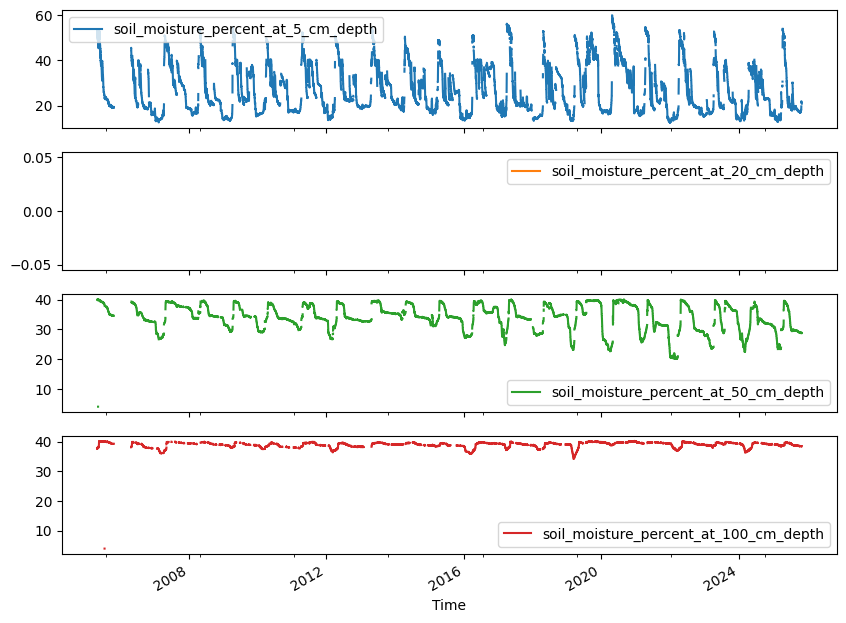

In [48]:
df_Clean_per,returns_per_clean=soil_temp_percentil_neighborhood_outliers(df=df_Soil_Temp_AGDM,low=0.00001,up=0.99999,th_returns=200,sens_stuck=50,segment_th = 2)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [49]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,60.0
soil_moisture_percent_at_20_cm_depth,NaN
soil_moisture_percent_at_50_cm_depth,40.2
soil_moisture_percent_at_100_cm_depth,40.2


In [50]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,12.3
soil_moisture_percent_at_20_cm_depth,NaN
soil_moisture_percent_at_50_cm_depth,4.0
soil_moisture_percent_at_100_cm_depth,4.0


In [51]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,162879
soil_moisture_percent_at_20_cm_depth,0
soil_moisture_percent_at_50_cm_depth,89551
soil_moisture_percent_at_100_cm_depth,53751


In [52]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,16848
soil_moisture_percent_at_20_cm_depth,179727
soil_moisture_percent_at_50_cm_depth,90176
soil_moisture_percent_at_100_cm_depth,125976


In [53]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,11549
soil_moisture_percent_at_20_cm_depth,9
soil_moisture_percent_at_50_cm_depth,84969
soil_moisture_percent_at_100_cm_depth,120769


# Z Scores Not Used


In [54]:
from cleaning_stephanie import soil_temp_zscores_neighborhood_outliers

/usr/local/lib/python3.13/dist-packages/numpy/lib/_nanfunctions_impl.py:1649: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Text(0.5, 0, 'Time')

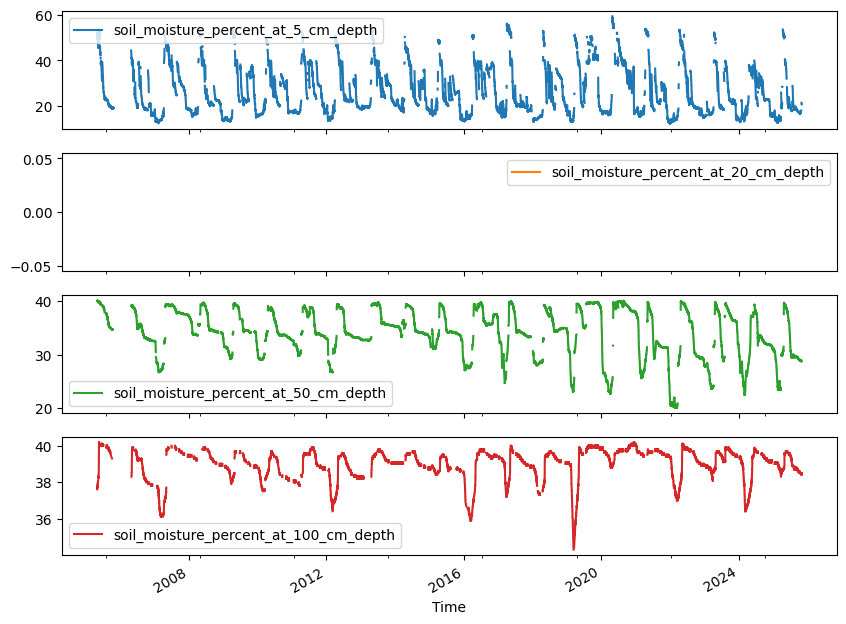

In [55]:
df_Clean_per,returns_per_clean=soil_temp_zscores_neighborhood_outliers(df=df_Soil_Temp_AGDM,zscr_sd=3,th_returns=2,sens_stuck=20,segment_th = 20)

df_Clean_per[variables].plot(
    subplots=True,
    figsize=(10, 8),
    sharex=True
)

plt.xlabel("Time")


In [56]:
df_Clean_per.max()

,0
soil_moisture_percent_at_5_cm_depth,59.3
soil_moisture_percent_at_20_cm_depth,NaN
soil_moisture_percent_at_50_cm_depth,40.2
soil_moisture_percent_at_100_cm_depth,40.2


In [57]:
df_Clean_per.min()

,0
soil_moisture_percent_at_5_cm_depth,12.3
soil_moisture_percent_at_20_cm_depth,NaN
soil_moisture_percent_at_50_cm_depth,20.1
soil_moisture_percent_at_100_cm_depth,34.3


In [58]:
df_Clean_per.notna().sum()

,0
soil_moisture_percent_at_5_cm_depth,128531
soil_moisture_percent_at_20_cm_depth,0
soil_moisture_percent_at_50_cm_depth,53444
soil_moisture_percent_at_100_cm_depth,40006


In [59]:
NaN_New=df_Clean_per.isna().sum()
NaN_New

,0
soil_moisture_percent_at_5_cm_depth,51196
soil_moisture_percent_at_20_cm_depth,179727
soil_moisture_percent_at_50_cm_depth,126283
soil_moisture_percent_at_100_cm_depth,139721


In [60]:
Anomalous=NaN_New-NaN_Original
Anomalous

,0
soil_moisture_percent_at_5_cm_depth,45897
soil_moisture_percent_at_20_cm_depth,9
soil_moisture_percent_at_50_cm_depth,121076
soil_moisture_percent_at_100_cm_depth,134514
